# Project for course Financial Econometrics I

## Group 3: Martin Beránek, Kryštof Hanzlík, Vít Voráček

We perform our analysis on Asset number 29.

We have used Chat-GPT for coding and to improve written English.

In [1]:
library(rugarch)
library(xts)
library(zoo)
library(forecast)

Loading required package: parallel


Attaching package: 'rugarch'


The following object is masked from 'package:stats':

    sigma


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



### Part 1

We begin by loading our data and examining its basic structure and descriptive statistics.

In [2]:
load("C:/Users/hanzl/Desktop/FSV 2.0/finecox/29.RData")
data <- amp
head(data)

                    ret          RV        RV_p        RV_n         RS
2010-01-05  0.019550147 0.009122223 0.008431910 0.003481071  1.7548397
2010-01-06  0.039444902 0.012116249 0.008310295 0.008817170 -0.6736002
2010-01-07 -0.001694460 0.015135076 0.012051791 0.009155591  1.2490207
2010-01-08  0.003141628 0.012663995 0.010544364 0.007013785  1.3053542
2010-01-11  0.013189847 0.019605939 0.015872339 0.011509201  1.0995151
2010-01-12  0.002139920 0.012787224 0.007823144 0.010114916 -0.6878332
                  RK
2010-01-05  5.141320
2010-01-06 11.025483
2010-01-07 10.246498
2010-01-08  6.058017
2010-01-11  6.417815
2010-01-12  4.430912

Now let's take a look whether there are any missing values.

In [3]:
sum(is.na(data))

[1] 0

Great, there are no missing values, now let's look at some basic descriptive statistics.

In [4]:
summary(data)

     Index                 ret                   RV          
 Min.   :2010-01-05   Min.   :-0.1395790   Min.   :0.004789  
 1st Qu.:2011-07-04   1st Qu.:-0.0085393   1st Qu.:0.008820  
 Median :2013-01-10   Median : 0.0012600   Median :0.011019  
 Mean   :2013-01-08   Mean   : 0.0006598   Mean   :0.012404  
 3rd Qu.:2014-07-14   3rd Qu.: 0.0100205   3rd Qu.:0.014164  
 Max.   :2016-01-22   Max.   : 0.1294856   Max.   :0.059498  
      RV_p               RV_n                RS                 RK        
 Min.   :0.002896   Min.   :0.002491   Min.   :-4.26695   Min.   : 2.223  
 1st Qu.:0.006144   1st Qu.:0.005934   1st Qu.:-0.56110   1st Qu.: 3.486  
 Median :0.007736   Median :0.007625   Median : 0.03808   Median : 4.526  
 Mean   :0.008745   Mean   :0.008623   Mean   : 0.06854   Mean   : 5.754  
 3rd Qu.:0.010126   3rd Qu.:0.009929   3rd Qu.: 0.59175   3rd Qu.: 6.516  
 Max.   :0.053939   Max.   :0.045319   Max.   : 5.79521   Max.   :44.760  

Returns are centered very close to zero, but the range from -13.96% to 12.95% shows some large extreme movements. The volatility measures are clearly right-skewed: for RV, the mean is above the median and the maximum 0.0595 is far above the third quartile 0.0142, indicating occasional volatility spikes. RV_p and RV_n are very similar, suggesting that positive and negative movements contribute almost equally to volatility. RS is close to zero on average, but its wide range from -4.27 to 5.80 shows that skewness changes substantially over time. The most notable feature is RK, whose mean 5.75 and maximum 44.76 indicate strong fat tails and extreme observations; this RK pattern points to non-normal returns.


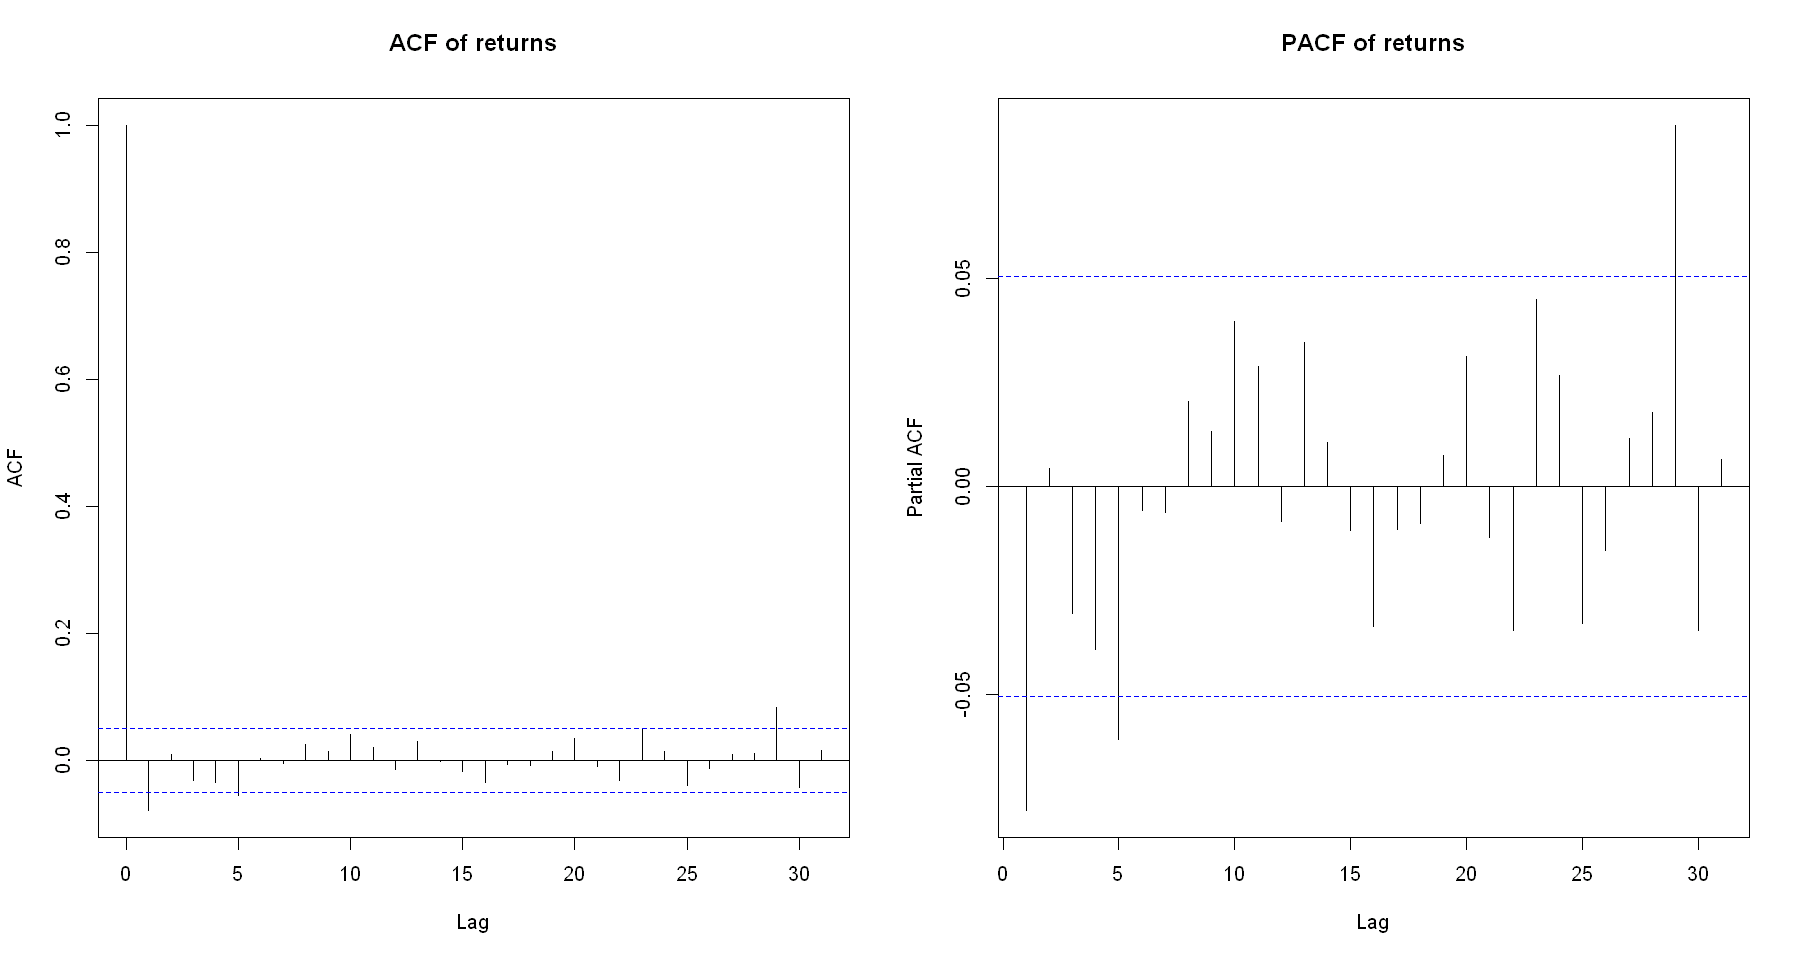

In [5]:
options(repr.plot.width = 15, repr.plot.height = 8)
par(mfrow = c(1, 2))
acf(data[, "ret"], na.action = na.pass, main = "ACF of returns")
pacf(data[, "ret"], na.action = na.pass, main = "PACF of returns")

Both graphs indicate some evidence of autocorrelation, although the overall pattern does not appear particularly strong. In the ACF plot, there are two significant spikes, mainly at lags 1 and 29, but their magnitudes are relatively small. The PACF plot shows three significant spikes at lags 1, 5, and 29, again suggesting only limited and irregular autocorrelation rather than a strong persistent structure.


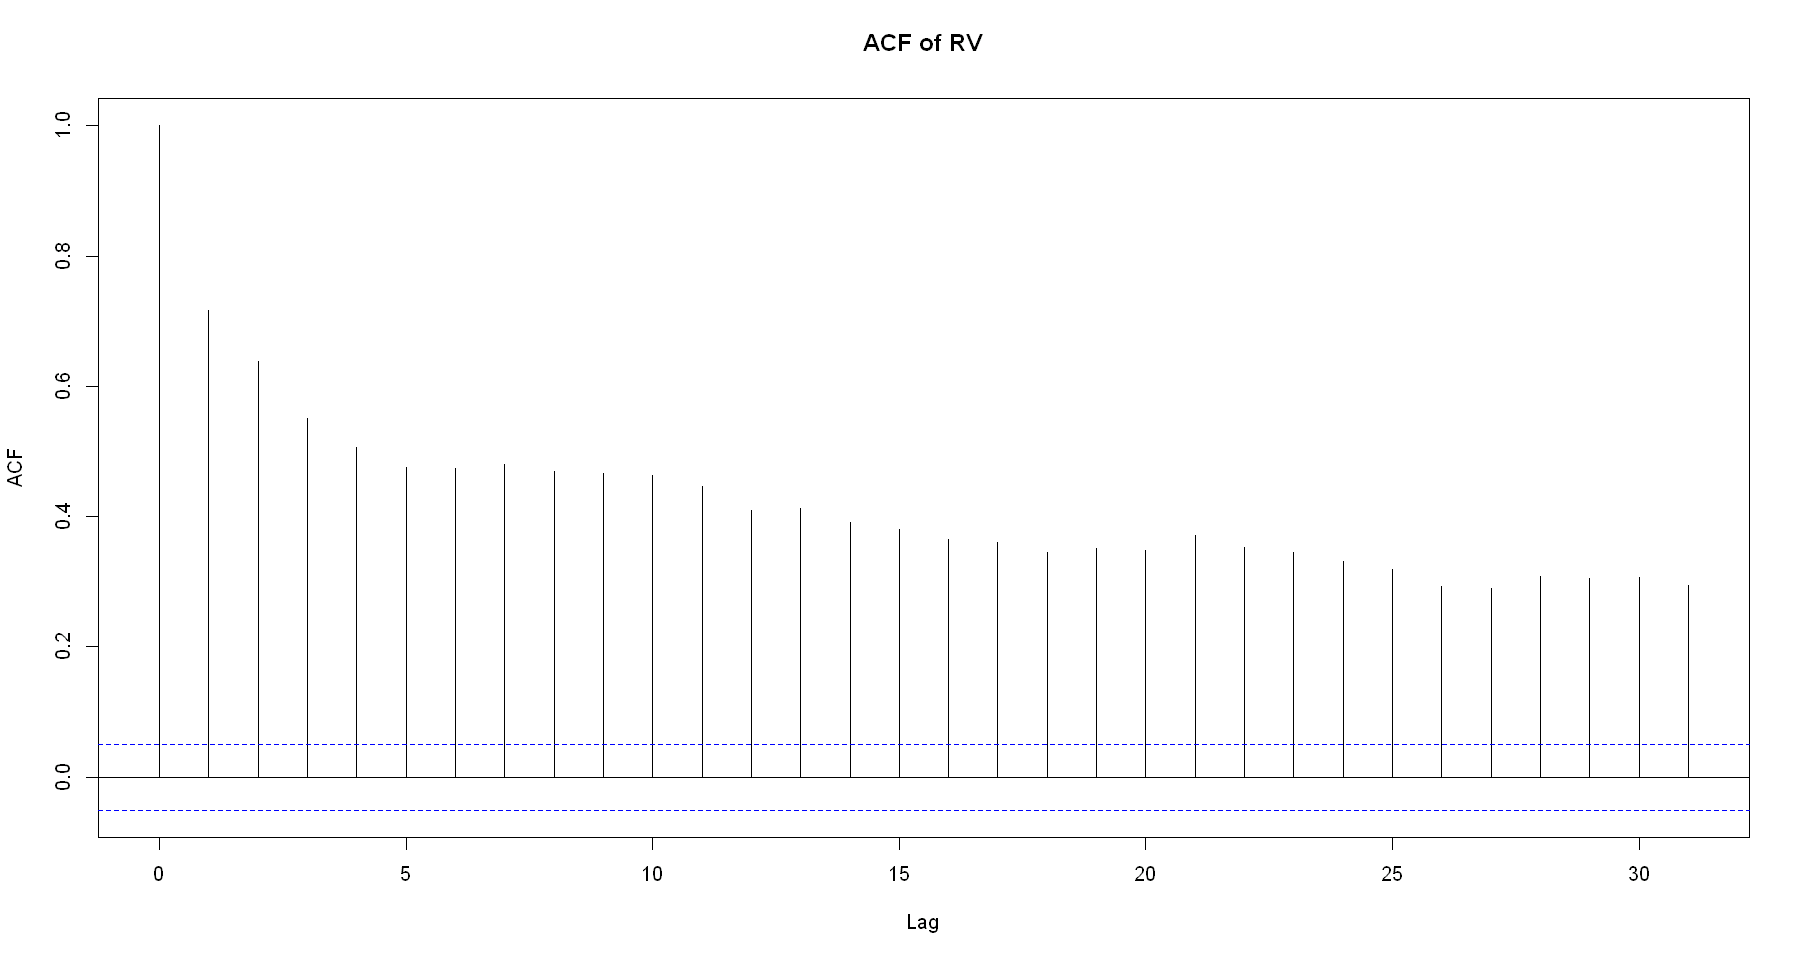

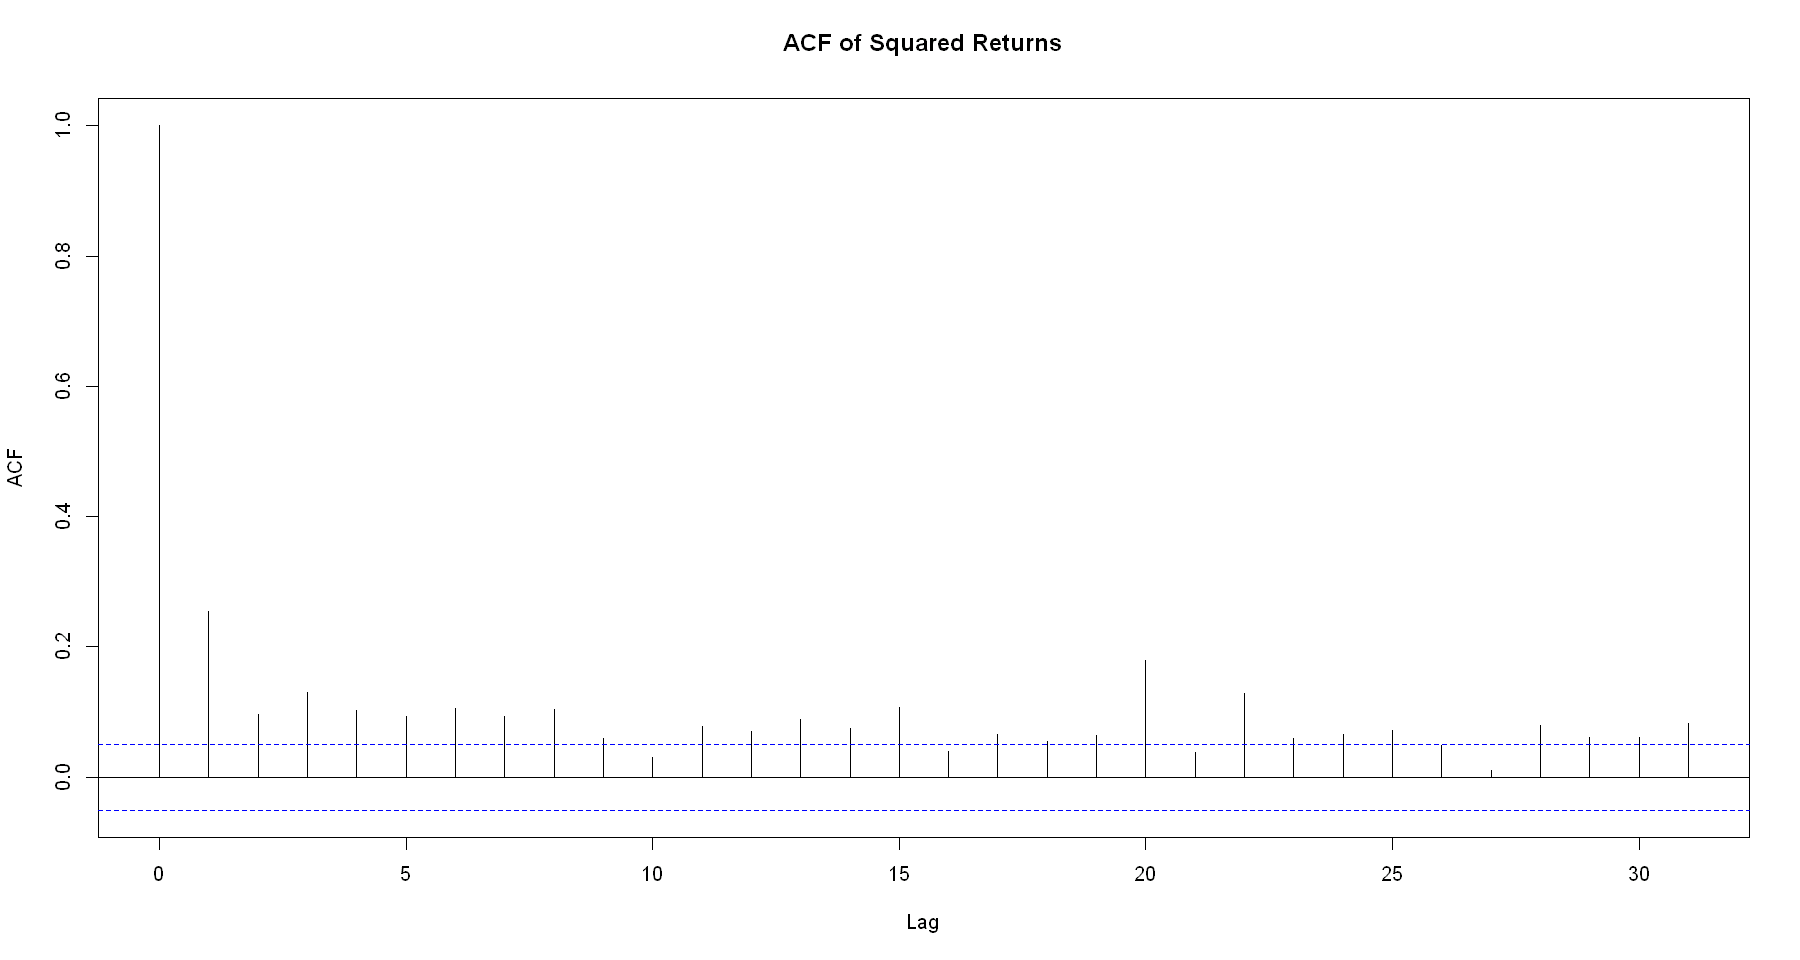

In [6]:
acf(data$RV, main = "ACF of RV")
acf(data$ret^2, main = "ACF of Squared Returns")

Both plots show clear signs of dependence, but the strength and pattern differ: the ACF of RV displays a long, slowly decaying sequence of significant autocorrelations, indicating strong and persistent structure in realized volatility, whereas the ACF of squared returns shows a dominant spike at lag 1 followed by a rapid decline, suggesting only short‑lived volatility clustering rather than sustained autocorrelation.

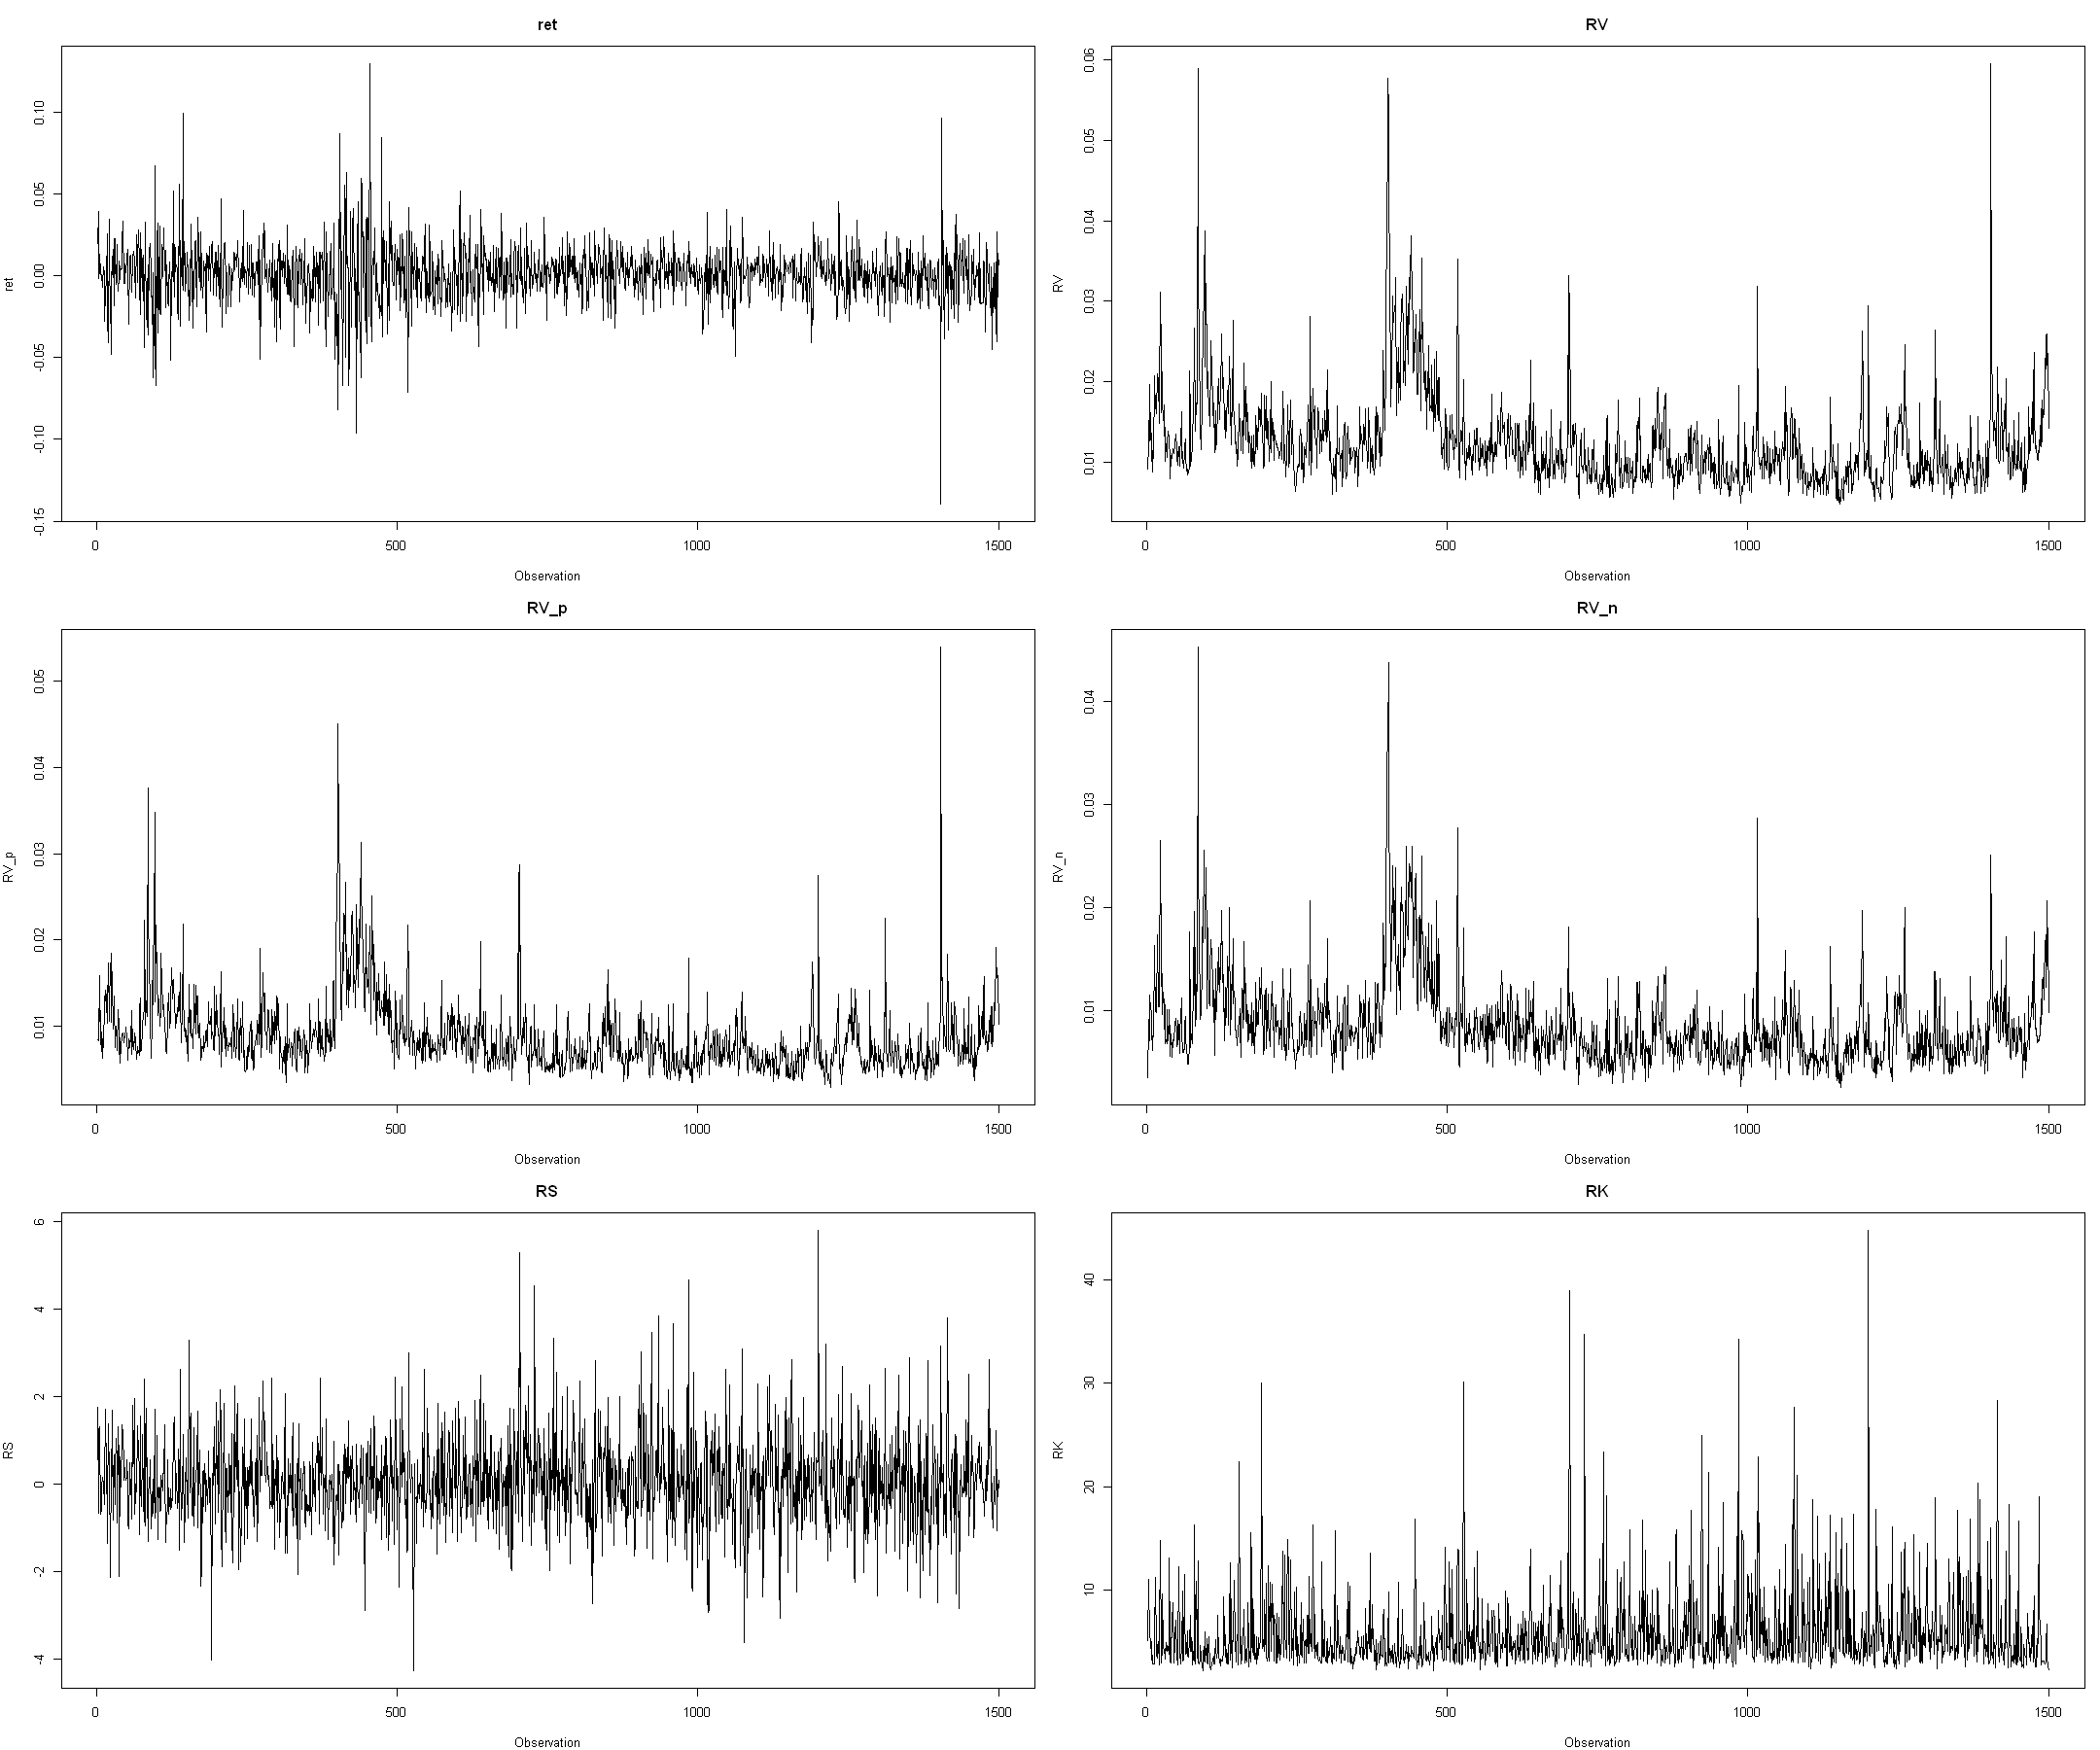

In [7]:
options(repr.plot.width = 18, repr.plot.height = 15)

var_names <- c("ret", "RV", "RV_p", "RV_n", "RS", "RK")

par(mfrow = c(3, 2), mar = c(4, 4, 3, 1))

for (i in 1:6) {
  plot(as.numeric(data[, i]),
       type = "l",
       main = var_names[i],
       xlab = "Observation",
       ylab = var_names[i])
}

par(mfrow = c(1, 1))

The plots show clear volatility clustering, with three main volatility clusters around observations 50-150, 300-500, and 1400-1500. These periods are visible especially in ret, RV, RV_p, and RV_n, where volatility spikes are concentrated rather than evenly spread across the sample.

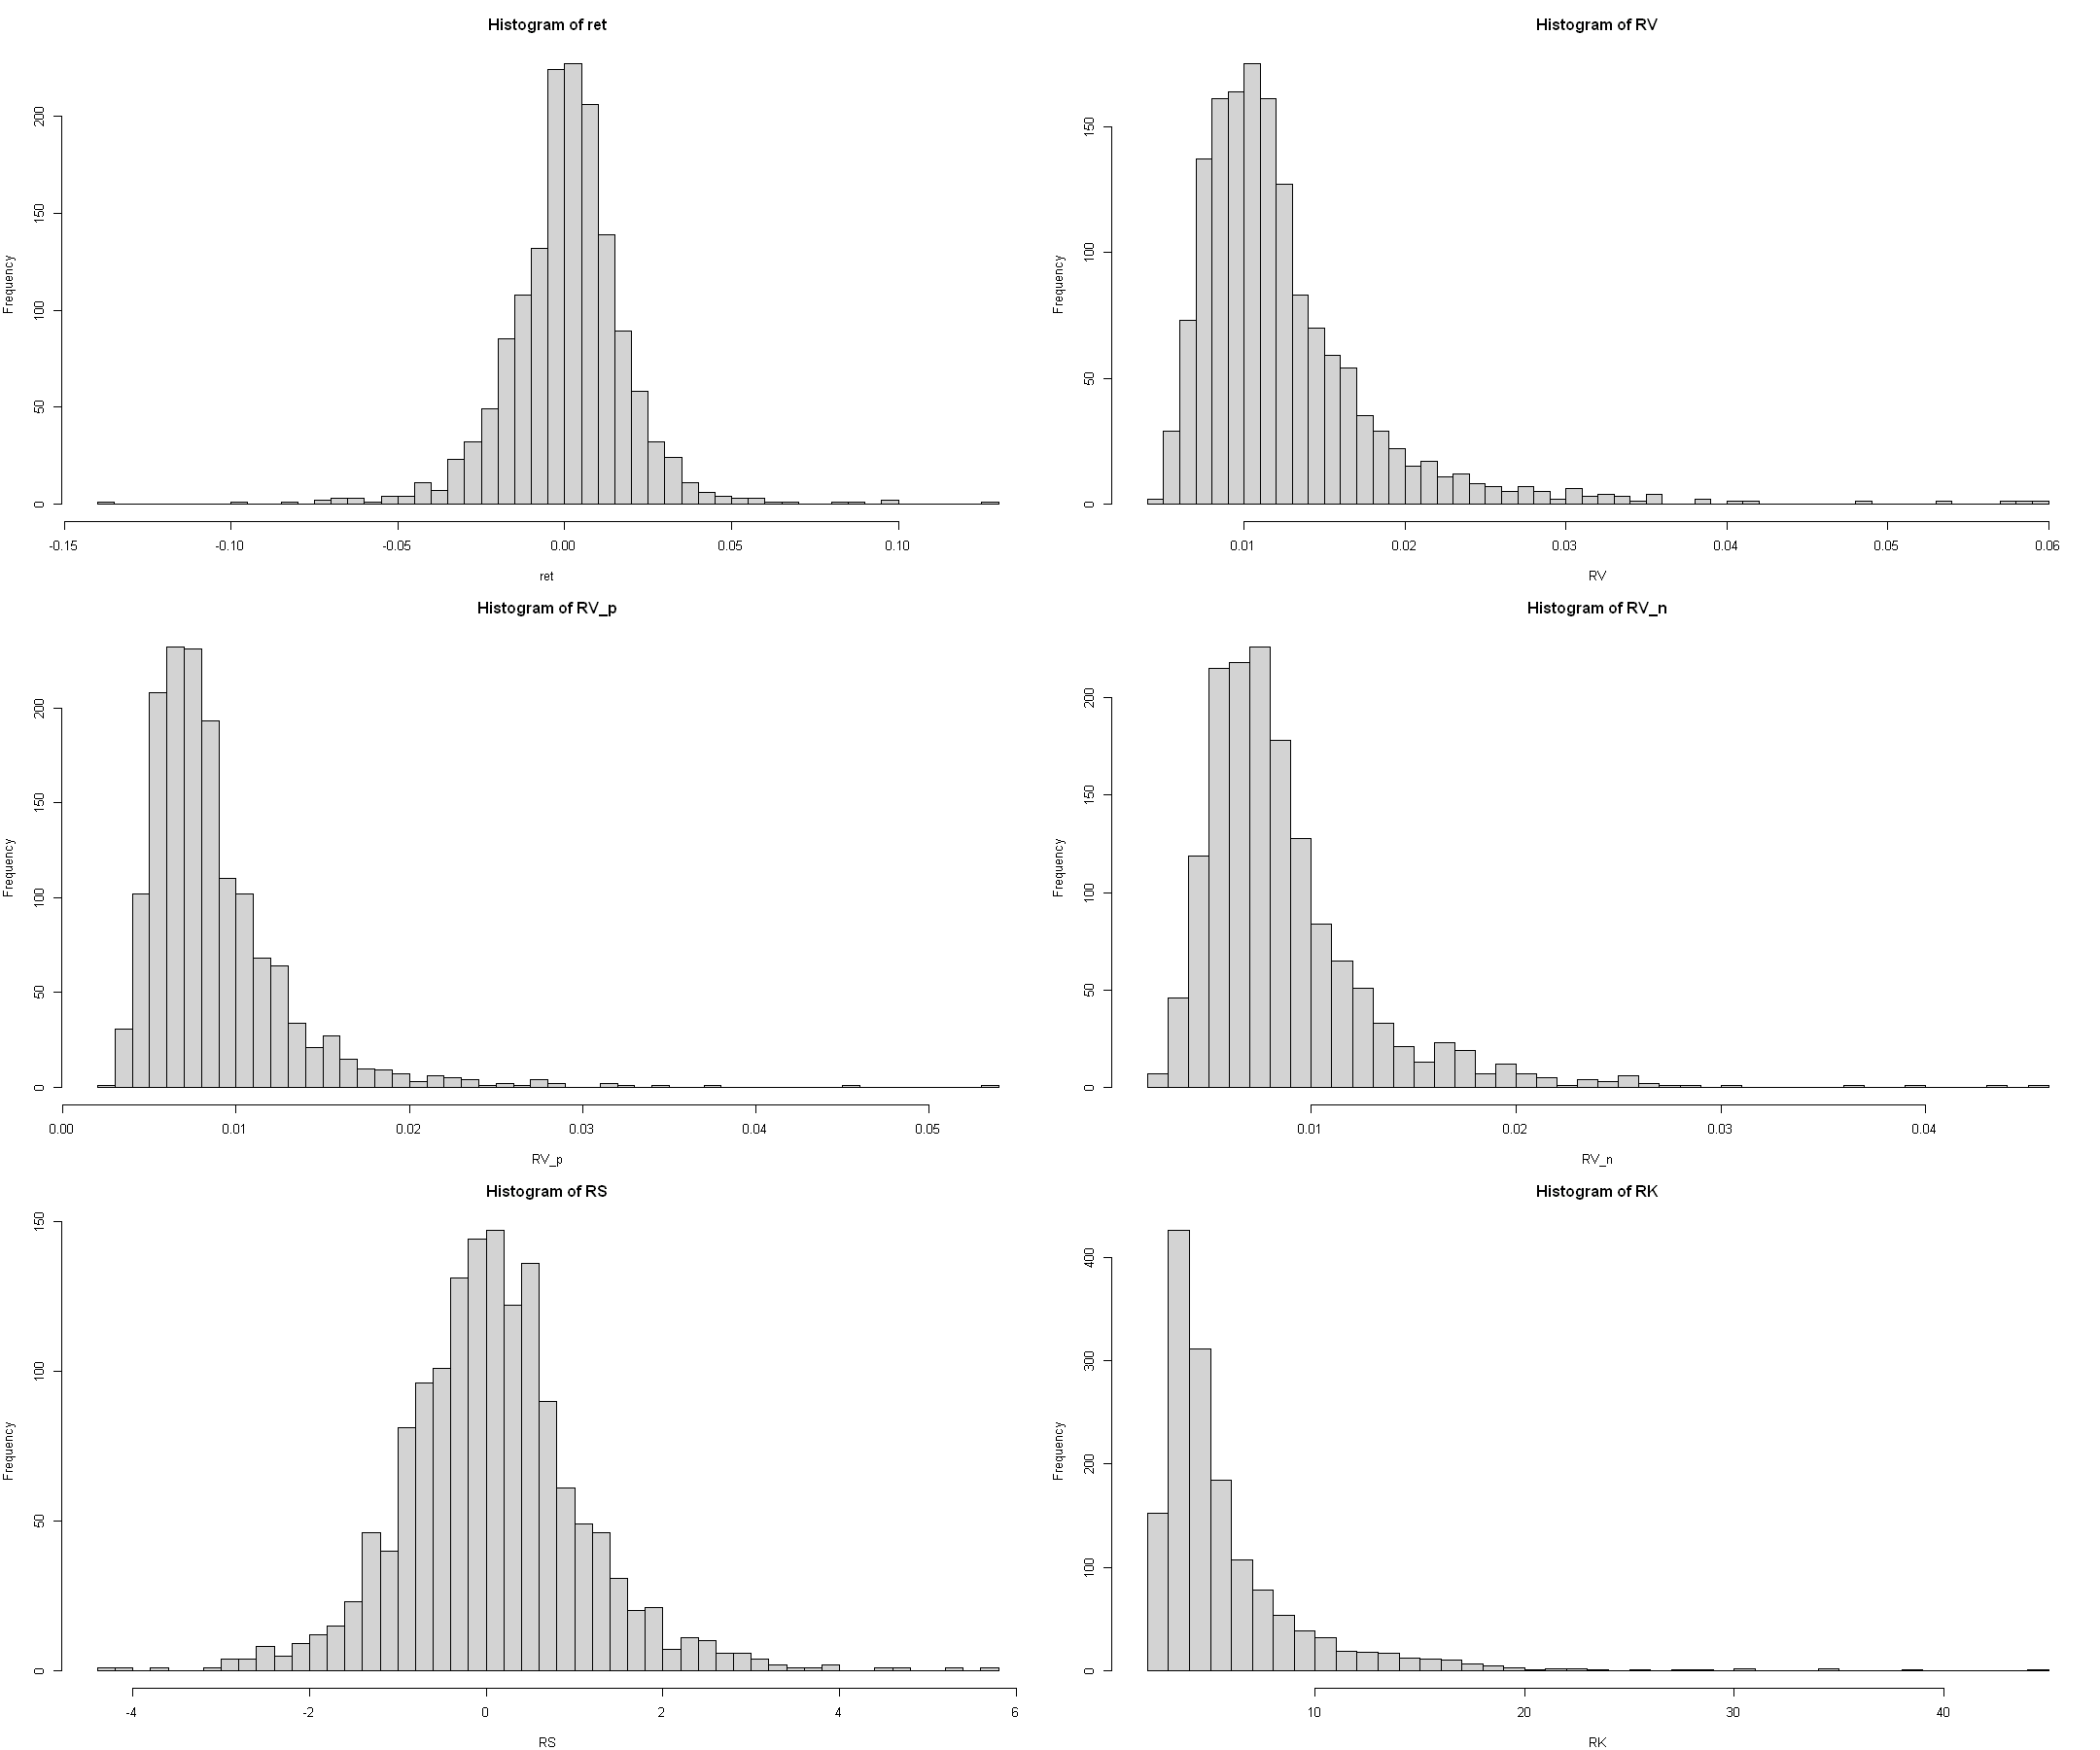

In [8]:
options(repr.plot.width = 18, repr.plot.height = 15)

var_names <- c("ret", "RV", "RV_p", "RV_n", "RS", "RK")

par(mfrow = c(3, 2), mar = c(4, 4, 3, 1))

for (i in seq_len(ncol(data))) {
  hist(data[, i],
       breaks = 40,
       main = paste("Histogram of", var_names[i]),
       xlab = var_names[i])
}



The histograms show that returns are centered close to zero, but with visible tails on both sides, indicating occasional large positive and negative returns. The volatility variables RV, RV_p, and RV_n are strongly right-skewed, with most observations concentrated at low values and a long right tail representing high-volatility episodes. RS is distributed around zero but has both negative and positive extreme values, which confirms that the asymmetry of returns varies over time. RK is also highly right-skewed, with most observations at relatively low levels but a few very large values, again pointing to fat tails and non-normal returns.

### Part 2

We start by preparing the dataset and creating the lagged variables required for the HAR-type models.

In [9]:
RV  <- as.numeric(data[, "RV"])
ret <- as.numeric(data[, "ret"])
RS  <- as.numeric(data[, "RS"])
RK  <- as.numeric(data[, "RK"])
dates <- index(data)
n <- length(RV)

HAR_data <- data.frame(
  RV_t = RV[23:n],
  RV_d = RV[22:(n - 1)],
  RV_w = sapply(23:n, function(i) mean(RV[(i - 5):(i - 1)], na.rm = TRUE)),
  RV_m = sapply(23:n, function(i) mean(RV[(i - 22):(i - 1)], na.rm = TRUE)),
  RS_d = RS[22:(n - 1)],
  RK_d = RK[22:(n - 1)]
)

AR(1)-RV is the simplest realized-volatility model. It explains current realized volatility only by its previous value, so it captures short-term persistence in volatility.

In [10]:
AR1_RV <- lm(RV_t ~ RV_d, data = HAR_data)

summary(AR1_RV)


Call:
lm(formula = RV_t ~ RV_d, data = HAR_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.022773 -0.002204 -0.000480  0.001443  0.042891 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0035110  0.0002464   14.25   <2e-16 ***
RV_d        0.7150535  0.0180639   39.59   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004008 on 1476 degrees of freedom
Multiple R-squared:  0.5149,	Adjusted R-squared:  0.5146 
F-statistic:  1567 on 1 and 1476 DF,  p-value: < 2.2e-16


The model confirms strong persistence in realized volatility, with the lagged RV coefficient equal to 0.715 and highly statistically significant. This means that high volatility tends to be followed by high volatility in the next period. The model explains about 51.5% of the variation in realized volatility, which is relatively strong for such a simple specification. However, because it only uses the one-period lag of RV, it cannot capture longer-term volatility dynamics.

HAR extends the idea of AR(1)-RV by using daily, weekly, and monthly realized volatility components. It is designed to capture volatility persistence over different time horizons, which is common in financial markets.

In [11]:
HAR <- lm(RV_t ~ RV_d + RV_w + RV_m, data = HAR_data)

summary(HAR)


Call:
lm(formula = RV_t ~ RV_d + RV_w + RV_m, data = HAR_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015675 -0.002130 -0.000494  0.001312  0.044902 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0011657  0.0003132   3.722 0.000205 ***
RV_d        0.4712637  0.0295271  15.960  < 2e-16 ***
RV_w        0.1790880  0.0465900   3.844 0.000126 ***
RV_m        0.2548417  0.0425227   5.993 2.58e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003829 on 1474 degrees of freedom
Multiple R-squared:  0.5579,	Adjusted R-squared:  0.557 
F-statistic: 620.1 on 3 and 1474 DF,  p-value: < 2.2e-16


The HAR model improves the fit compared with AR(1)-RV, increasing the adjusted R-squared from about 0.515 to 0.557. All three components - daily, weekly, and monthly realized volatility - are positive and statistically significant. The daily component has the strongest coefficient, but the weekly and monthly components also matter, confirming that volatility persistence operates at multiple horizons. This supports the use of the HAR structure instead of relying only on the previous day's volatility.

HAR-RS adds realized skewness to the HAR model. This allows the model to account for asymmetry in the return distribution, meaning whether extreme movements are more concentrated on the positive or negative side.

In [12]:
HAR_RS <- lm(RV_t ~ RV_d + RV_w + RV_m + RS_d, data = HAR_data)

summary(HAR_RS)


Call:
lm(formula = RV_t ~ RV_d + RV_w + RV_m + RS_d, data = HAR_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015631 -0.002064 -0.000478  0.001327  0.044796 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.191e-03  3.127e-04   3.810 0.000145 ***
RV_d         4.728e-01  2.947e-02  16.042  < 2e-16 ***
RV_w         1.780e-01  4.650e-02   3.828 0.000134 ***
RV_m         2.537e-01  4.244e-02   5.978 2.82e-09 ***
RS_d        -2.575e-04  9.648e-05  -2.668 0.007703 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003821 on 1473 degrees of freedom
Multiple R-squared:   0.56,	Adjusted R-squared:  0.5588 
F-statistic: 468.8 on 4 and 1473 DF,  p-value: < 2.2e-16


Adding realized skewness slightly improves the model fit, with adjusted R-squared rising from 0.557 to 0.559. The coefficient on RS_d is negative and statistically significant, suggesting that higher realized skewness is associated with slightly lower future realized volatility. However, the improvement is small, so realized skewness adds some information but does not substantially change the main HAR dynamics. The daily, weekly, and monthly RV components remain positive and significant.

HAR-Rskew-RKurt further adds realized kurtosis. Besides volatility persistence and skewness, it also captures the effect of fat tails and extreme observations on future volatility.

In [13]:
HAR_RSkew_RKurt <- lm(RV_t ~ RV_d + RV_w + RV_m + RS_d + RK_d, data = HAR_data)

summary(HAR_RSkew_RKurt)


Call:
lm(formula = RV_t ~ RV_d + RV_w + RV_m + RS_d + RK_d, data = HAR_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015114 -0.002009 -0.000522  0.001409  0.043813 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.728e-03  3.576e-04   7.630 4.19e-14 ***
RV_d         5.484e-01  3.022e-02  18.143  < 2e-16 ***
RV_w         1.165e-01  4.606e-02   2.528   0.0116 *  
RV_m         2.184e-01  4.171e-02   5.235 1.89e-07 ***
RS_d        -1.138e-04  9.592e-05  -1.186   0.2358    
RK_d        -2.228e-04  2.687e-05  -8.290 2.53e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003736 on 1472 degrees of freedom
Multiple R-squared:  0.5797,	Adjusted R-squared:  0.5782 
F-statistic:   406 on 5 and 1472 DF,  p-value: < 2.2e-16


Adding realized kurtosis produces the best fit among the HAR-type models, with adjusted R-squared increasing to about 0.578. The kurtosis coefficient is negative and highly significant, indicating that realized kurtosis contains additional predictive information for future RV. After including kurtosis, realized skewness becomes statistically insignificant, suggesting that kurtosis captures more relevant information about the distributional shape of returns. The RV components remain significant, although the weekly component becomes weaker than in the simpler HAR models.

Realized GARCH jointly models returns and realized volatility. It combines a traditional GARCH structure with observed realized volatility, making it more informative than standard GARCH when high-frequency-based volatility measures are available.

In [14]:
ret_xts <- data[, "ret"]
RV_xts  <- data[, "RV"]

valid <- is.finite(as.numeric(ret_xts)) & is.finite(as.numeric(RV_xts))

ret_xts <- ret_xts[valid]
RV_xts  <- RV_xts[valid]

In [15]:
spec_realGARCH <- ugarchspec(
  variance.model = list(
    model = "realGARCH",
    garchOrder = c(1, 1)
  ),
  mean.model = list(
    armaOrder = c(0, 0),
    include.mean = TRUE
  ),
  distribution.model = "norm"
)

fit_realGARCH <- ugarchfit(
  spec = spec_realGARCH,
  data = ret_xts,
  realizedVol = RV_xts,
  solver = "hybrid"
)

fit_realGARCH


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000769    0.000349   2.2018 0.027678
omega   0.660404    0.224641   2.9398 0.003284
alpha1  1.000000    0.080917  12.3583 0.000000
beta1   0.546211    0.030454  17.9356 0.000000
eta11  -0.045348    0.006375  -7.1134 0.000000
eta21   0.027197    0.003077   8.8384 0.000000
delta   0.387678    0.020165  19.2249 0.000000
lambda  0.236342    0.004319  54.7175 0.000000
xi     -1.214887    0.168267  -7.2200 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000769    0.000315   2.4362 0.014842
omega   0.660404    0.309224   2.1357 0.032705
alpha1  1.000000    0.172123   5.8098 0.000000
beta1

The Realized GARCH model fits the data well and achieves a higher log-likelihood than the ARMA-GARCH model (4201.1 vs. 4051.8) and a better AIC (-5.5895 vs. -5.3944). Most parameters are highly significant even under robust standard errors, indicating strong volatility persistence and a meaningful link between returns and realized volatility. The Ljung-Box and ARCH-LM tests mostly suggest that serial correlation and remaining ARCH effects are adequately handled.

ARMA-GARCH models the conditional mean and conditional volatility of returns. The ARMA part captures possible dependence in returns, while the GARCH part captures volatility clustering and time-varying risk.

In [16]:
spec_arma_garch <- ugarchspec(
  variance.model = list(
    model = "sGARCH",
    garchOrder = c(1, 1)
  ),
  mean.model = list(
    armaOrder = c(1, 1),
    include.mean = TRUE
  ),
  distribution.model = "norm"
)

fit_arma_garch <- ugarchfit(
  spec = spec_arma_garch,
  data = ret_xts,
  solver = "hybrid"
)

fit_arma_garch


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.001420    0.000320   4.4368 0.000009
ar1     0.666927    0.326917   2.0401 0.041345
ma1    -0.710647    0.307717  -2.3094 0.020920
omega   0.000019    0.000005   4.0713 0.000047
alpha1  0.196136    0.031795   6.1688 0.000000
beta1   0.760635    0.035381  21.4986 0.000000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.001420    0.000374   3.8007 0.000144
ar1     0.666927    0.420073   1.5876 0.112367
ma1    -0.710647    0.397553  -1.7876 0.073848
omega   0.000019    0.000012   1.5534 0.120335
alpha1  0.196136    0.099325   1.9747 0.048303
beta1   0.760635    0.111961   6.7938 0.000000

LogLike

The ARMA-GARCH model captures volatility clustering well, with significant GARCH parameters alpha1 and beta1; their sum is about 0.957, indicating very persistent conditional volatility. The residual diagnostics are generally good, as the Ljung-Box and ARCH-LM tests do not show serious remaining autocorrelation or ARCH effects. However, the ARMA terms become weaker under robust standard errors. Compared with Realized GARCH, it has a lower log-likelihood and worse information criteria, which suggests that using realized volatility directly improves the in-sample fit.

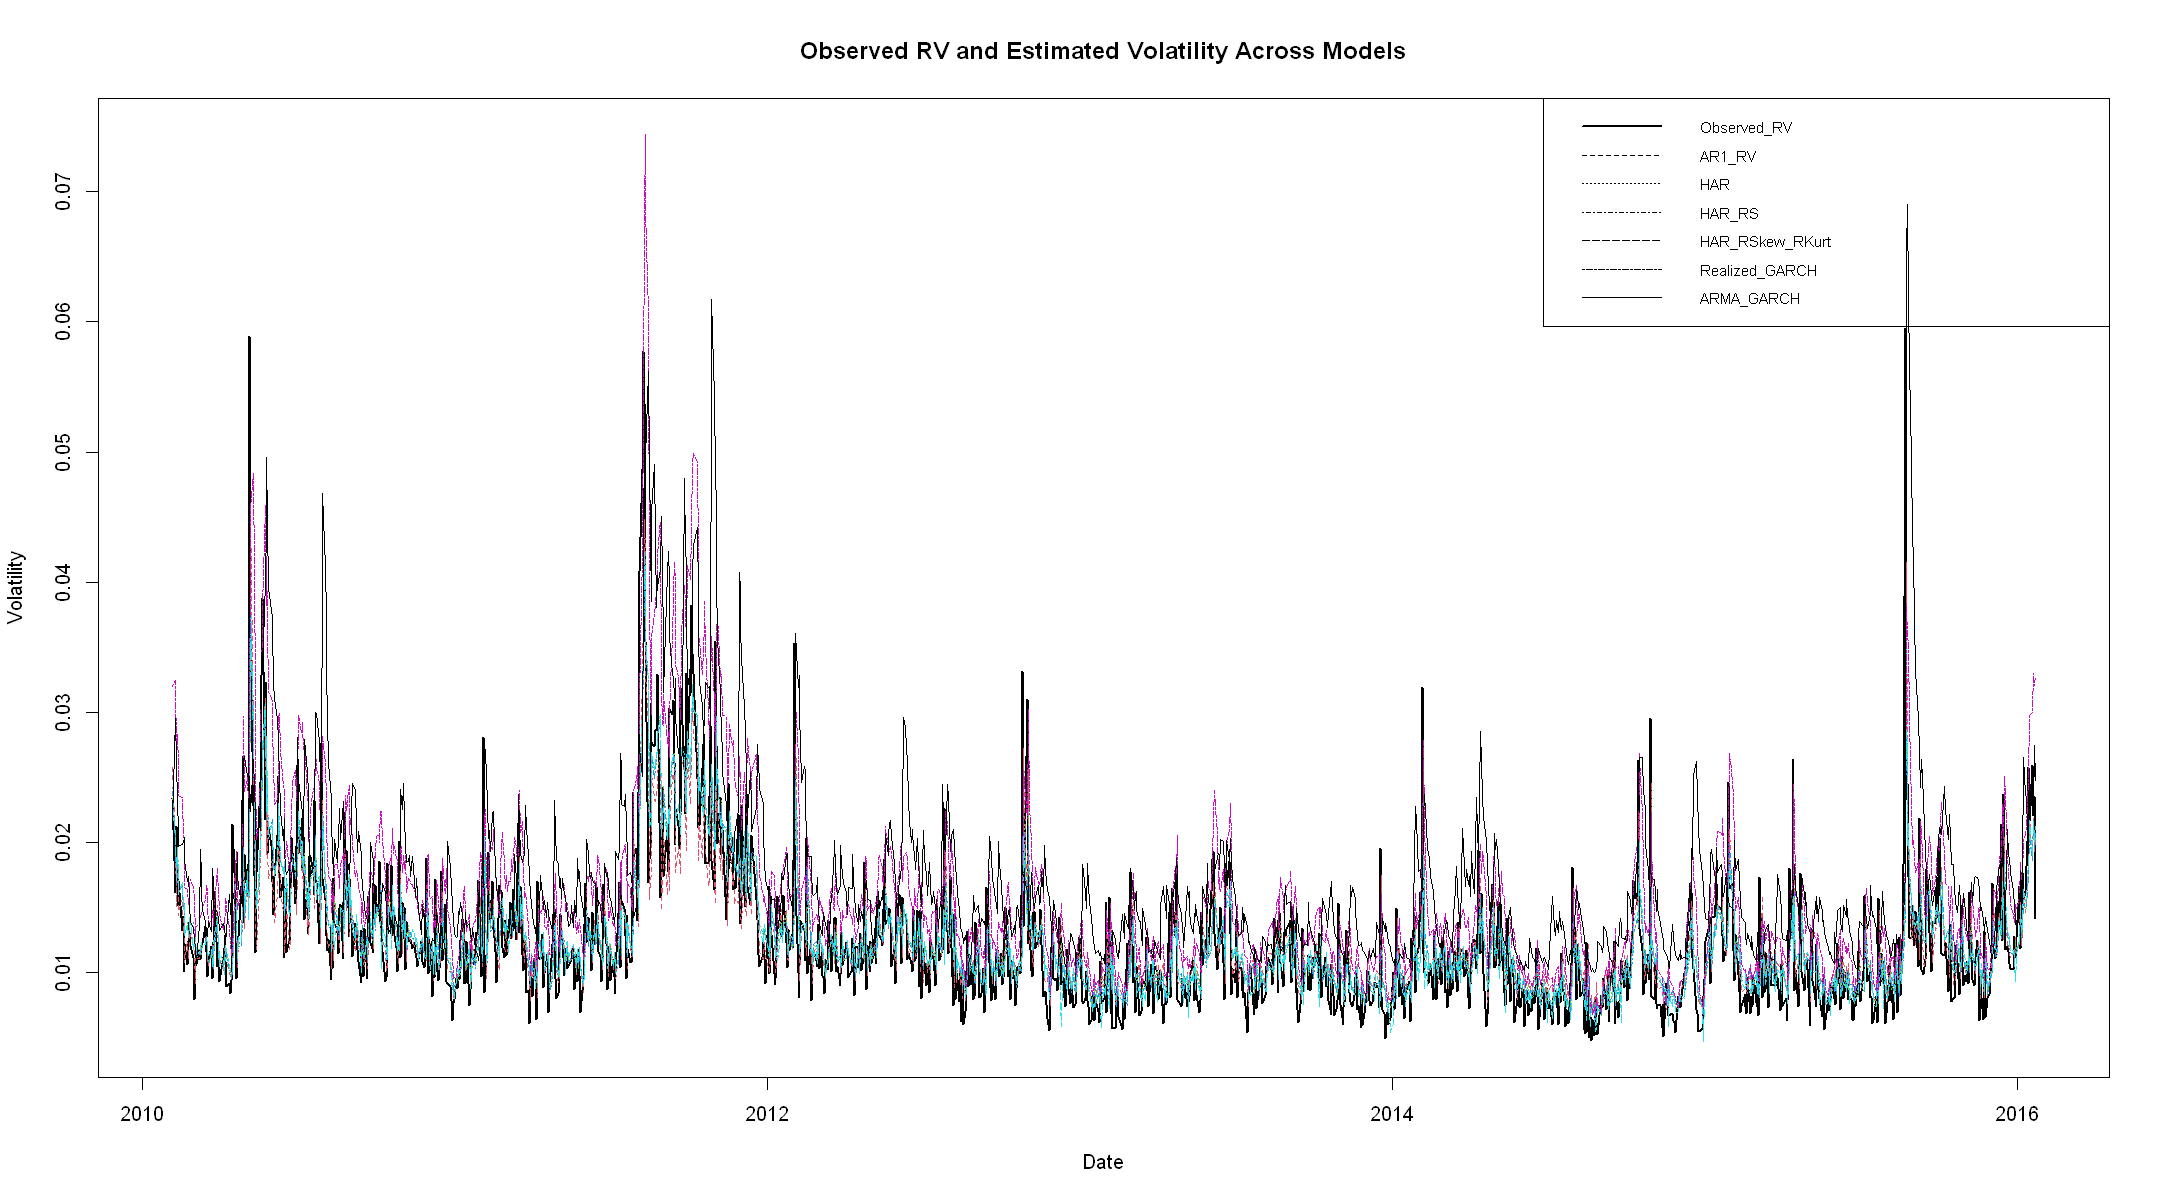

In [17]:
options(repr.plot.width = 18, repr.plot.height = 10)

har_dates <- index(RV_xts)[23:length(RV_xts)]

fit_AR1_RV <- xts(fitted(AR1_RV), order.by = har_dates)
fit_HAR <- xts(fitted(HAR), order.by = har_dates)
fit_HAR_RS <- xts(fitted(HAR_RS), order.by = har_dates)
fit_HAR_RSkew_RKurt <- xts(fitted(HAR_RSkew_RKurt), order.by = har_dates)

fit_realGARCH_vol <- sigma(fit_realGARCH)
fit_arma_garch_vol <- sigma(fit_arma_garch)

vol_compare <- merge(
  RV_xts,
  fit_AR1_RV,
  fit_HAR,
  fit_HAR_RS,
  fit_HAR_RSkew_RKurt,
  fit_realGARCH_vol,
  fit_arma_garch_vol
)

colnames(vol_compare) <- c(
  "Observed_RV",
  "AR1_RV",
  "HAR",
  "HAR_RS",
  "HAR_RSkew_RKurt",
  "Realized_GARCH",
  "ARMA_GARCH"
)

vol_compare <- na.omit(vol_compare)

matplot(
  index(vol_compare),
  coredata(vol_compare),
  type = "l",
  lty = 1:7,
  lwd = c(2, rep(1.5, 6)),
  xlab = "Date",
  ylab = "Volatility",
  main = "Observed RV and Estimated Volatility Across Models"
)

legend(
  "topright",
  legend = colnames(vol_compare),
  lty = 1:7,
  lwd = c(2, rep(1.5, 6)),
  cex = 0.75
)

The figure compares observed realized volatility with volatility estimates obtained from several competing models. Overall, all fitted series follow the broad movement of observed volatility reasonably well. The models capture the main periods of increased volatility, especially the large volatility clusters around 2011-2012 and near the end of the sample. This suggests that the models are able to reproduce the persistent component of volatility and the general time-varying pattern of the data.

However, the fitted lines overlap strongly, so the graph does not provide a clear visual ranking of the models. The main differences appear during sharp volatility spikes, where observed realized volatility rises more abruptly than the model estimates. This indicates that the models capture normal volatility dynamics relatively well, but they smooth out extreme short-term movements

### Part 3

#### Creating HAR-type regressors

In [18]:
RV  <- as.numeric(data$RV)
ret <- as.numeric(data$ret)
RS  <- as.numeric(data$RS)
RK  <- as.numeric(data$RK)

In [ ]:
RV_w <- rollapply(
  RV,
  width = 5,
  FUN = mean,
  align = "right",
  fill = NA
)

RV_m <- rollapply(
  RV,
  width = 22,
  FUN = mean,
  align = "right",
  fill = NA
)

HAR_full <- data.frame(
  date = dates,
  RV_t = RV,
  RV_d = c(NA, RV[-length(RV)]),
  RV_w = c(NA, RV_w[-length(RV_w)]),
  RV_m = c(NA, RV_m[-length(RV_m)]),
  RS_d = c(NA, RS[-length(RS)]),
  RK_d = c(NA, RK[-length(RK)])
)

HAR_full <- na.omit(HAR_full)
HAR_full

,date,RV_t,RV_d,RV_w,RV_m,RS_d,RK_d
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
23,2010-02-05,0.023399126,0.031099754,0.02096810,0.01602584,-2.13614779,14.844927
24,2010-02-08,0.016146544,0.023399126,0.02144716,0.01667479,0.79602098,3.409648
25,2010-02-09,0.021217710,0.016146544,0.02063485,0.01685799,-0.36959997,2.948298
26,2010-02-10,0.017779314,0.021217710,0.02192455,0.01713447,0.68036535,4.344067
27,2010-02-11,0.015174741,0.017779314,0.02192849,0.01736699,1.68215377,9.681313
28,2010-02-12,0.017063463,0.015174741,0.01874349,0.01716557,-0.82202772,4.798112
29,2010-02-16,0.013247326,0.017063463,0.01747635,0.01735994,0.66816938,3.970678
30,2010-02-17,0.014288023,0.013247326,0.01689651,0.01734357,0.49933864,3.871776
31,2010-02-18,0.010105837,0.014288023,0.01551057,0.01747524,-0.47618256,4.376186


#### Preparing settings for the forecast

In [20]:
window_size <- 750

oos_start <- window_size + 1

oos_indices <- oos_start:nrow(HAR_full)

n_oos <- length(oos_indices)

model_names <- c(
  "AR1_RV",
  "HAR",
  "HAR_RS",
  "HAR_RSkew_RKurt",
  "Realized_GARCH",
  "ARMA_GARCH"
)

#### Creating matrices for storage

In [21]:
exp_forecasts <- matrix(
  NA,
  nrow = n_oos,
  ncol = length(model_names)
)

roll_forecasts <- matrix(
  NA,
  nrow = n_oos,
  ncol = length(model_names)
)

colnames(exp_forecasts) <- model_names
colnames(roll_forecasts) <- model_names

realized_oos <- HAR_full$RV_t[oos_indices]

#### Specifying models

In [22]:
spec_realGARCH <- ugarchspec(
  variance.model = list(
    model = "realGARCH",
    garchOrder = c(1,1)
  ),
  mean.model = list(
    armaOrder = c(0,0),
    include.mean = TRUE
  ),
  distribution.model = "norm"
)

spec_realGARCH


*---------------------------------*
*       GARCH Model Spec          *
*---------------------------------*

Conditional Variance Dynamics 	
------------------------------------
GARCH Model		: realGARCH(1,1)
Variance Targeting	: FALSE 

Conditional Mean Dynamics
------------------------------------
Mean Model		: ARFIMA(0,0,0)
Include Mean		: TRUE 
GARCH-in-Mean		: FALSE 

Conditional Distribution
------------------------------------
Distribution	:  norm 
Includes Skew	:  FALSE 
Includes Shape	:  FALSE 
Includes Lambda	:  FALSE 


In [23]:
spec_arma_garch <- ugarchspec(
  variance.model = list(
    model = "sGARCH",
    garchOrder = c(1,1)
  ),
  mean.model = list(
    armaOrder = c(1,1),
    include.mean = TRUE
  ),
  distribution.model = "norm"
)
spec_arma_garch


*---------------------------------*
*       GARCH Model Spec          *
*---------------------------------*

Conditional Variance Dynamics 	
------------------------------------
GARCH Model		: sGARCH(1,1)
Variance Targeting	: FALSE 

Conditional Mean Dynamics
------------------------------------
Mean Model		: ARFIMA(1,0,1)
Include Mean		: TRUE 
GARCH-in-Mean		: FALSE 

Conditional Distribution
------------------------------------
Distribution	:  norm 
Includes Skew	:  FALSE 
Includes Shape	:  FALSE 
Includes Lambda	:  FALSE 


#### Forecasting the expanding, rolling windows

In [24]:
for(i in seq_along(oos_indices)) {

  t <- oos_indices[i]

  train <- HAR_full[1:(t - 1), ]

  ##########################################################
  # AR(1)-RV
  ##########################################################

  fit_ar1 <- lm(RV_t ~ RV_d, data = train)

  exp_forecasts[i, "AR1_RV"] <-
    predict(
      fit_ar1,
      newdata = HAR_full[t, ]
    )

  ##########################################################
  # HAR
  ##########################################################

  fit_har <- lm(
    RV_t ~ RV_d + RV_w + RV_m,
    data = train
  )

  exp_forecasts[i, "HAR"] <-
    predict(
      fit_har,
      newdata = HAR_full[t, ]
    )

  ##########################################################
  # HAR-RS
  ##########################################################

  fit_har_rs <- lm(
    RV_t ~ RV_d + RV_w + RV_m + RS_d,
    data = train
  )

  exp_forecasts[i, "HAR_RS"] <-
    predict(
      fit_har_rs,
      newdata = HAR_full[t, ]
    )

  ##########################################################
  # HAR-RSkew-RKurt
  ##########################################################

  fit_har_rk <- lm(
    RV_t ~ RV_d + RV_w + RV_m + RS_d + RK_d,
    data = train
  )

  exp_forecasts[i, "HAR_RSkew_RKurt"] <-
    predict(
      fit_har_rk,
      newdata = HAR_full[t, ]
    )

  ##########################################################
  # Realized GARCH
  ##########################################################

  ret_train <- data$ret[1:(t - 1)]
  rv_train  <- data$RV[1:(t - 1)]

  # Added tryCatch and changed solver to hybrid
  fit_rg <- tryCatch({
    ugarchfit(spec = spec_realGARCH, data = ret_train, realizedVol = rv_train, solver = "hybrid")
  }, error = function(e) { 
    return(NULL) 
  }, warning = function(w) {
    suppressWarnings(ugarchfit(spec = spec_realGARCH, data = ret_train, realizedVol = rv_train, solver = "hybrid"))
  })

  # Safe forecast extraction
  if(!is.null(fit_rg) && !inherits(fit_rg, "try-error")) {
    fc_rg <- tryCatch({
      ugarchforecast(fit_rg, n.ahead = 1)
    }, error = function(e) { return(NULL) })
    
    if(!is.null(fc_rg)) {
      exp_forecasts[i, "Realized_GARCH"] <- as.numeric(sigma(fc_rg))
    } else {
      exp_forecasts[i, "Realized_GARCH"] <- ifelse(i > 1, exp_forecasts[i-1, "Realized_GARCH"], NA)
    }
  } else {
    exp_forecasts[i, "Realized_GARCH"] <- ifelse(i > 1, exp_forecasts[i-1, "Realized_GARCH"], NA)
  }

  ##########################################################
  # ARMA-GARCH
  ##########################################################
  
  # Added tryCatch and changed solver to hybrid
  fit_ag <- tryCatch({
    ugarchfit(spec = spec_arma_garch, data = ret_train, solver = "hybrid")
  }, error = function(e) { 
    return(NULL) 
  }, warning = function(w) {
    suppressWarnings(ugarchfit(spec = spec_arma_garch, data = ret_train, solver = "hybrid"))
  })

  # Safe forecast extraction
  if(!is.null(fit_ag) && !inherits(fit_ag, "try-error")) {
    fc_ag <- tryCatch({
      ugarchforecast(fit_ag, n.ahead = 1)
    }, error = function(e) { return(NULL) })
    
    if(!is.null(fc_ag)) {
      exp_forecasts[i, "ARMA_GARCH"] <- as.numeric(sigma(fc_ag))
    } else {
      exp_forecasts[i, "ARMA_GARCH"] <- ifelse(i > 1, exp_forecasts[i-1, "ARMA_GARCH"], NA)
    }
  } else {
    exp_forecasts[i, "ARMA_GARCH"] <- ifelse(i > 1, exp_forecasts[i-1, "ARMA_GARCH"], NA)
  }
}

In [25]:
for(i in seq_along(oos_indices)) {

  t <- oos_indices[i]
  start_idx <- t - window_size
  train <- HAR_full[start_idx:(t - 1), ]

  ##########################################################
  # AR(1)-RV
  ##########################################################
  fit_ar1 <- lm(RV_t ~ RV_d, data = train)
  roll_forecasts[i, "AR1_RV"] <- predict(fit_ar1, newdata = HAR_full[t, ])

  ##########################################################
  # HAR
  ##########################################################
  fit_har <- lm(RV_t ~ RV_d + RV_w + RV_m, data = train)
  roll_forecasts[i, "HAR"] <- predict(fit_har, newdata = HAR_full[t, ])

  ##########################################################
  # HAR-RS
  ##########################################################
  fit_har_rs <- lm(RV_t ~ RV_d + RV_w + RV_m + RS_d, data = train)
  roll_forecasts[i, "HAR_RS"] <- predict(fit_har_rs, newdata = HAR_full[t, ])

  ##########################################################
  # HAR-RSkew-RKurt
  ##########################################################
  fit_har_rk <- lm(RV_t ~ RV_d + RV_w + RV_m + RS_d + RK_d, data = train)
  roll_forecasts[i, "HAR_RSkew_RKurt"] <- predict(fit_har_rk, newdata = HAR_full[t, ])

  ##########################################################
  # Realized GARCH
  ##########################################################
  ret_train <- data$ret[(t - window_size):(t - 1)]
  rv_train  <- data$RV[(t - window_size):(t - 1)]

  fit_rg <- tryCatch({
    ugarchfit(spec = spec_realGARCH, data = ret_train, realizedVol = rv_train, solver = "hybrid")
  }, error = function(e) { 
    return(NULL) 
  }, warning = function(w) {
    suppressWarnings(ugarchfit(spec = spec_realGARCH, data = ret_train, realizedVol = rv_train, solver = "hybrid"))
  })

  if(!is.null(fit_rg) && !inherits(fit_rg, "try-error")) {
    fc_rg <- tryCatch({
      ugarchforecast(fit_rg, n.ahead = 1)
    }, error = function(e) { return(NULL) })
    
    if(!is.null(fc_rg)) {
      roll_forecasts[i, "Realized_GARCH"] <- as.numeric(sigma(fc_rg))
    } else {
      roll_forecasts[i, "Realized_GARCH"] <- ifelse(i > 1, roll_forecasts[i-1, "Realized_GARCH"], NA)
    }
  } else {
    roll_forecasts[i, "Realized_GARCH"] <- ifelse(i > 1, roll_forecasts[i-1, "Realized_GARCH"], NA)
  }

  ##########################################################
  # ARMA-GARCH
  ##########################################################
  fit_ag <- tryCatch({
    ugarchfit(spec = spec_arma_garch, data = ret_train, solver = "hybrid")
  }, error = function(e) { 
    return(NULL) 
  }, warning = function(w) {
    suppressWarnings(ugarchfit(spec = spec_arma_garch, data = ret_train, solver = "hybrid"))
  })

  if(!is.null(fit_ag) && !inherits(fit_ag, "try-error")) {
    fc_ag <- tryCatch({
      ugarchforecast(fit_ag, n.ahead = 1)
    }, error = function(e) { return(NULL) })
    
    if(!is.null(fc_ag)) {
      roll_forecasts[i, "ARMA_GARCH"] <- as.numeric(sigma(fc_ag))
    } else {
      roll_forecasts[i, "ARMA_GARCH"] <- ifelse(i > 1, roll_forecasts[i-1, "ARMA_GARCH"], NA)
    }
  } else {
    roll_forecasts[i, "ARMA_GARCH"] <- ifelse(i > 1, roll_forecasts[i-1, "ARMA_GARCH"], NA)
  }
}


#### Forecast errors + loss functions 

In [26]:
exp_errors <- exp_forecasts - realized_oos
roll_errors <- roll_forecasts - realized_oos

In [27]:
head(exp_errors)
head(roll_errors)

AR1_RV,HAR,HAR_RS,HAR_RSkew_RKurt,Realized_GARCH,ARMA_GARCH
1.577765e-03,0.0004642255,0.0004961356,0.0006652011,-0.0025992995,0.006734972
2.073998e-03,0.0010611976,0.0009125744,0.0015588864,-0.0028057895,0.006888966
2.810169e-03,0.0018236452,0.0009781679,0.0011503680,-0.0018531277,0.007687534
2.880102e-03,0.0021575215,0.0024309174,0.0028845613,-0.0004283135,0.008280115
3.745889e-05,-0.0005096547,-0.0005986075,-0.0003840738,-0.0021701295,0.005890291
1.629914e-03,0.0006238788,0.0009536035,0.0016633386,-0.0027662312,0.005570549


AR1_RV,HAR,HAR_RS,HAR_RSkew_RKurt,Realized_GARCH,ARMA_GARCH
1.577765e-03,0.0004642255,0.0004961356,0.0006652011,-0.0026442763,0.006734972
2.068066e-03,0.0010616182,0.0009112524,0.0015590321,-0.0027906972,0.006890576
2.800528e-03,0.0018218226,0.0009725209,0.0011597234,-0.0018008351,0.007723479
2.861851e-03,0.0021528030,0.0024247330,0.0028785058,-0.0003493618,0.008294060
1.553802e-05,-0.0005185044,-0.0006085476,-0.0003873052,-0.0020886918,0.005885896
1.615912e-03,0.0006211970,0.0009465670,0.0016561268,-0.0026999989,0.005564287


In [28]:
loss_function <- function(errors) {

  mse <- colMeans(errors^2, na.rm = TRUE)

  mae <- colMeans(abs(errors), na.rm = TRUE)

  data.frame(
    Model = names(mse),
    MSE = mse,
    MAE = mae
  )
}

exp_loss <- loss_function(exp_errors)
roll_loss <- loss_function(roll_errors)

exp_loss
roll_loss

,Model,MSE,MAE
,<chr>,<dbl>,<dbl>
AR1_RV,AR1_RV,1.339665e-05,0.002405657
HAR,HAR,1.198843e-05,0.002253232
HAR_RS,HAR_RS,1.204614e-05,0.002264899
HAR_RSkew_RKurt,HAR_RSkew_RKurt,1.149283e-05,0.002203994
Realized_GARCH,Realized_GARCH,3.323604e-05,0.004152958
ARMA_GARCH,ARMA_GARCH,5.527077e-05,0.005177178


,Model,MSE,MAE
,<chr>,<dbl>,<dbl>
AR1_RV,AR1_RV,1.308291e-05,0.002336898
HAR,HAR,1.209872e-05,0.002242953
HAR_RS,HAR_RS,1.220409e-05,0.002256617
HAR_RSkew_RKurt,HAR_RSkew_RKurt,1.165908e-05,0.002195571
Realized_GARCH,Realized_GARCH,1.424315e-02,0.009798605
ARMA_GARCH,ARMA_GARCH,4.541774e-05,0.004666226


The MSE and MAE results show a large performance gap between the two groups of models. All of the HAR specifications performed well, keeping MSEs consistently low at around 1.15e-05. The GARCH models, however, struggled out-of-sample. The Realized GARCH was particularly inconsistent in the rolling window, suggesting it has a hard time adjusting as old data drops out of the sample.

#### Diebold-Mariano tests

In [29]:
dm_test_matrix <- function(realized, forecasts) {

  models <- colnames(forecasts)
  n_models <- length(models)
  results <- matrix(NA, nrow = n_models, ncol = n_models)
  rownames(results) <- models
  colnames(results) <- models

  for(i in 1:n_models) {
    for(j in 1:n_models) {
      if(i != j) {
        
        # Calculate individual forecast errors
        e1 <- forecasts[, i] - realized
        e2 <- forecasts[, j] - realized
        
        # Extract the HAC-robust p-value using the standard forecast package
        # h=1 for 1-step ahead forecasts, power=2 for MSE loss
        test_result <- dm.test(e1, e2, h = 1, power = 2)
        results[i, j] <- test_result$p.value
        
      }
    }
  }

  return(results)
}

dm_expanding <- dm_test_matrix(
  realized_oos,
  exp_forecasts
)

dm_rolling <- dm_test_matrix(
  realized_oos,
  roll_forecasts
)

dm_expanding
dm_rolling

,AR1_RV,HAR,HAR_RS,HAR_RSkew_RKurt,Realized_GARCH,ARMA_GARCH
AR1_RV,NA,2.915102e-02,4.590949e-02,3.507528e-03,1.061936e-16,1.739204e-08
HAR,2.915102e-02,NA,5.841402e-01,3.446535e-02,5.961930e-24,4.618139e-09
HAR_RS,4.590949e-02,5.841402e-01,NA,8.575070e-03,1.221843e-23,4.663915e-09
HAR_RSkew_RKurt,3.507528e-03,3.446535e-02,8.575070e-03,NA,5.287372e-23,3.301048e-09
Realized_GARCH,1.061936e-16,5.961930e-24,1.221843e-23,5.287372e-23,NA,4.107303e-03
ARMA_GARCH,1.739204e-08,4.618139e-09,4.663915e-09,3.301048e-09,4.107303e-03,NA


,AR1_RV,HAR,HAR_RS,HAR_RSkew_RKurt,Realized_GARCH,ARMA_GARCH
AR1_RV,NA,1.179044e-03,3.684168e-03,4.477694e-05,0.3049018,2.820375e-05
HAR,1.179044e-03,NA,3.053128e-01,4.814694e-02,0.3048683,1.588028e-05
HAR_RS,3.684168e-03,3.053128e-01,NA,1.057305e-02,0.3048719,1.692047e-05
HAR_RSkew_RKurt,4.477694e-05,4.814694e-02,1.057305e-02,NA,0.3048533,1.268327e-05
Realized_GARCH,3.049018e-01,3.048683e-01,3.048719e-01,3.048533e-01,NA,3.060029e-01
ARMA_GARCH,2.820375e-05,1.588028e-05,1.692047e-05,1.268327e-05,0.3060029,NA


The Diebold-Mariano tests back up what we saw in the loss functions. The p-values are practically zero when comparing the HAR models to the GARCH models, proving that the GARCH underperformance is highly statistically significant. Additionally, the tests show that our most complex model (HAR-RSkew-RKurt) beats both the AR(1)-RV and standard HAR models at the 5% level. This shows that adding skewness and kurtosis helps with out-of-sample forecasting.

#### Mintzer-Zarnowitz regressions

In [30]:
mz_results <- function(realized, forecasts) {

  models <- colnames(forecasts)

  output <- list()

  for(m in models) {

    df <- data.frame(
      realized = realized,
      forecast = forecasts[, m]
    )

    fit <- lm(realized ~ forecast, data = df)

    output[[m]] <- summary(fit)
  }

  return(output)
}

mz_expanding <- mz_results(
  realized_oos,
  exp_forecasts
)

mz_rolling <- mz_results(
  realized_oos,
  roll_forecasts
)

The Mincer-Zarnowitz regressions further highlight the performance gap. The HAR models show strong predictive power, with slope coefficients ($\beta$) close to 1 and R-squared values around 0.30, meaning they effectively capture the variance of out-of-sample volatility. On the other hand, the GARCH models display near-zero R-squared values and statistically insignificant slopes, indicating a complete breakdown in out-of-sample predictive efficiency.

In [31]:
mz_expanding

$AR1_RV

Call:
lm(formula = realized ~ forecast, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012754 -0.001960 -0.000492  0.001117  0.045073 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0026685  0.0004938   5.404 8.84e-08 ***
forecast    0.7029692  0.0430920  16.313  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.0035 on 726 degrees of freedom
Multiple R-squared:  0.2682,	Adjusted R-squared:  0.2672 
F-statistic: 266.1 on 1 and 726 DF,  p-value: < 2.2e-16


$HAR

Call:
lm(formula = realized ~ forecast, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.009767 -0.001983 -0.000548  0.001224  0.045640 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0016457  0.0005204   3.162  0.00163 ** 
forecast    0.8319880  0.0477301  17.431  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.

In [32]:
mz_rolling

$AR1_RV

Call:
lm(formula = realized ~ forecast, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012953 -0.002081 -0.000555  0.001130  0.046543 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0017799  0.0006024   2.955  0.00323 ** 
forecast    0.8150876  0.0552970  14.740  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00359 on 726 degrees of freedom
Multiple R-squared:  0.2303,	Adjusted R-squared:  0.2293 
F-statistic: 217.3 on 1 and 726 DF,  p-value: < 2.2e-16


$HAR

Call:
lm(formula = realized ~ forecast, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.010926 -0.002074 -0.000494  0.001168  0.046317 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0008016  0.0005919   1.354    0.176    
forecast    0.9278678  0.0556042  16.687   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0

#### Forecast error plots

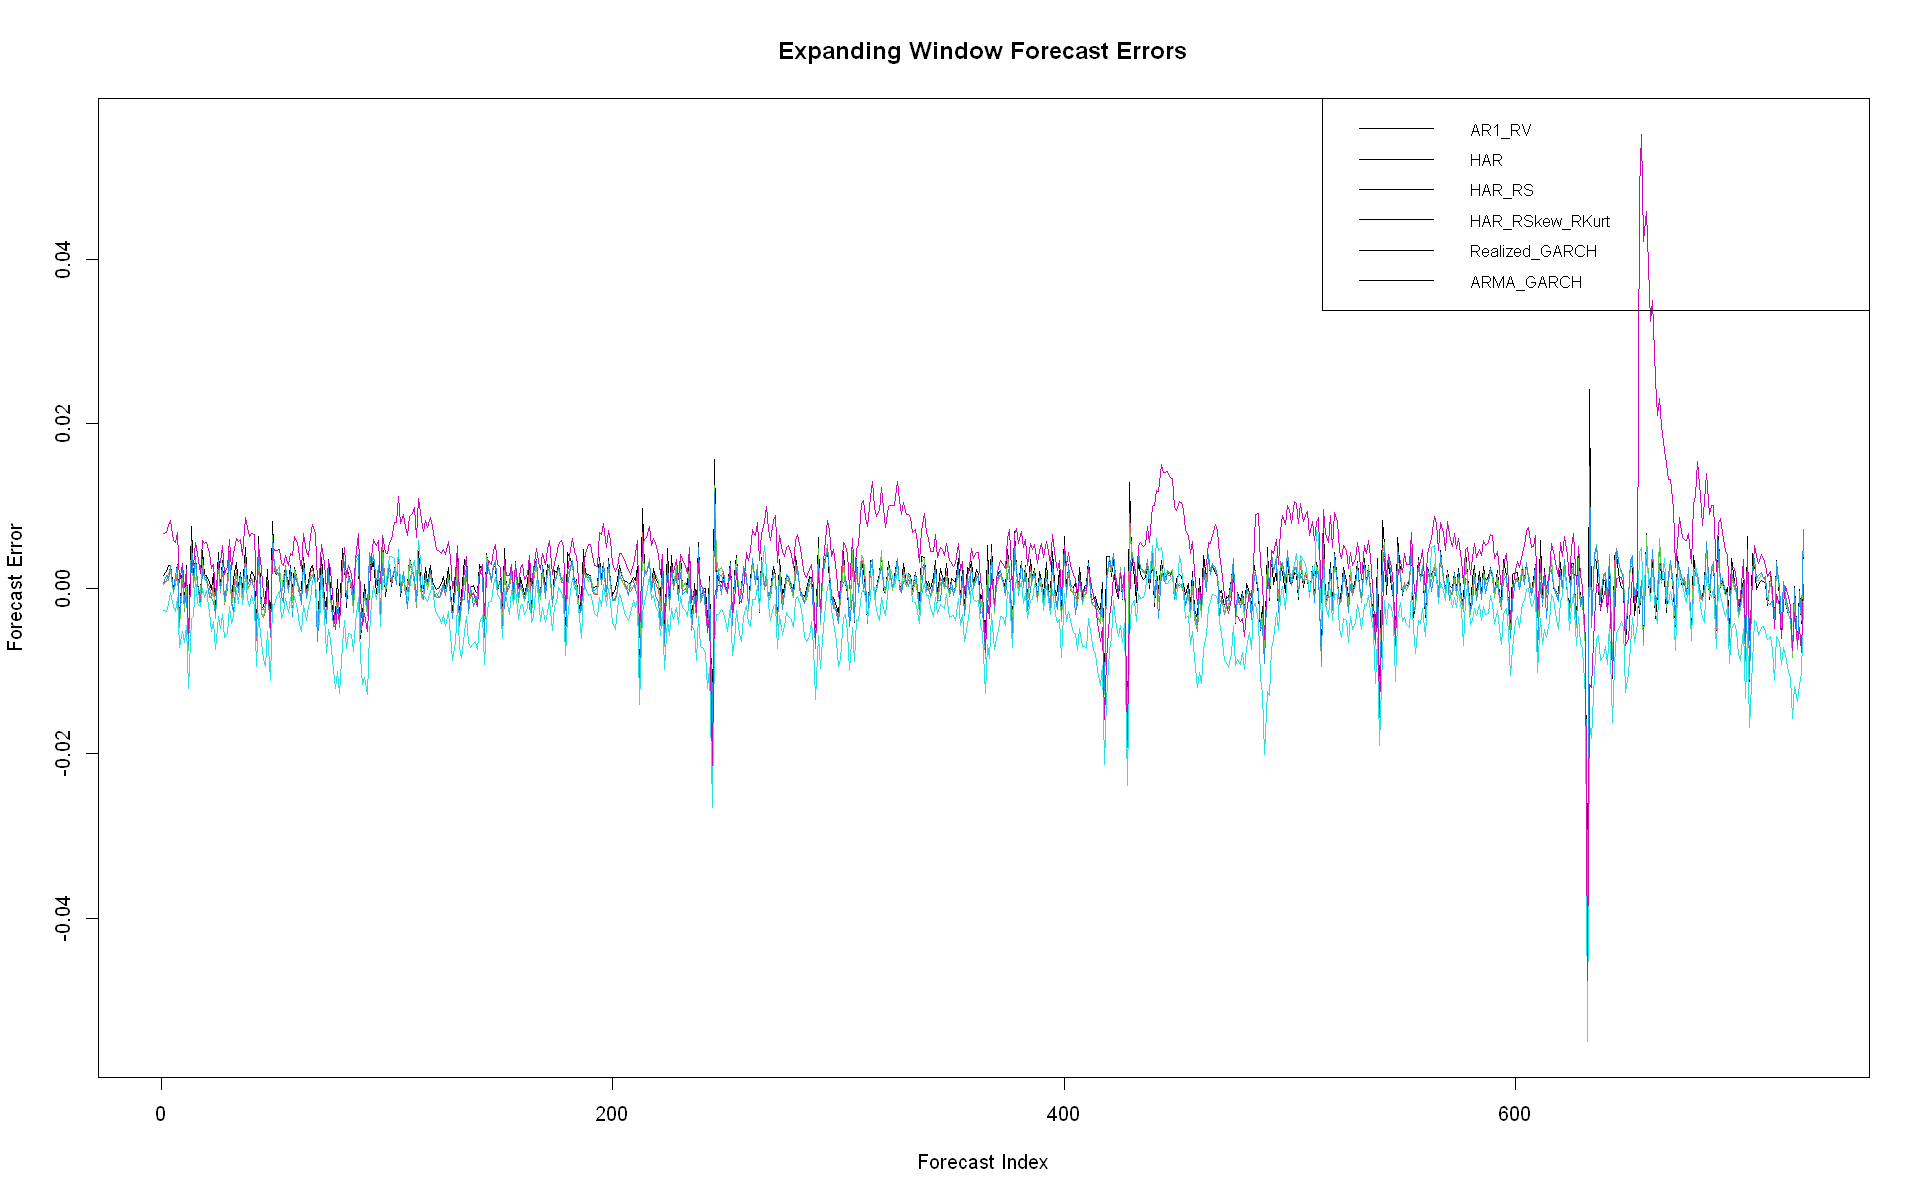

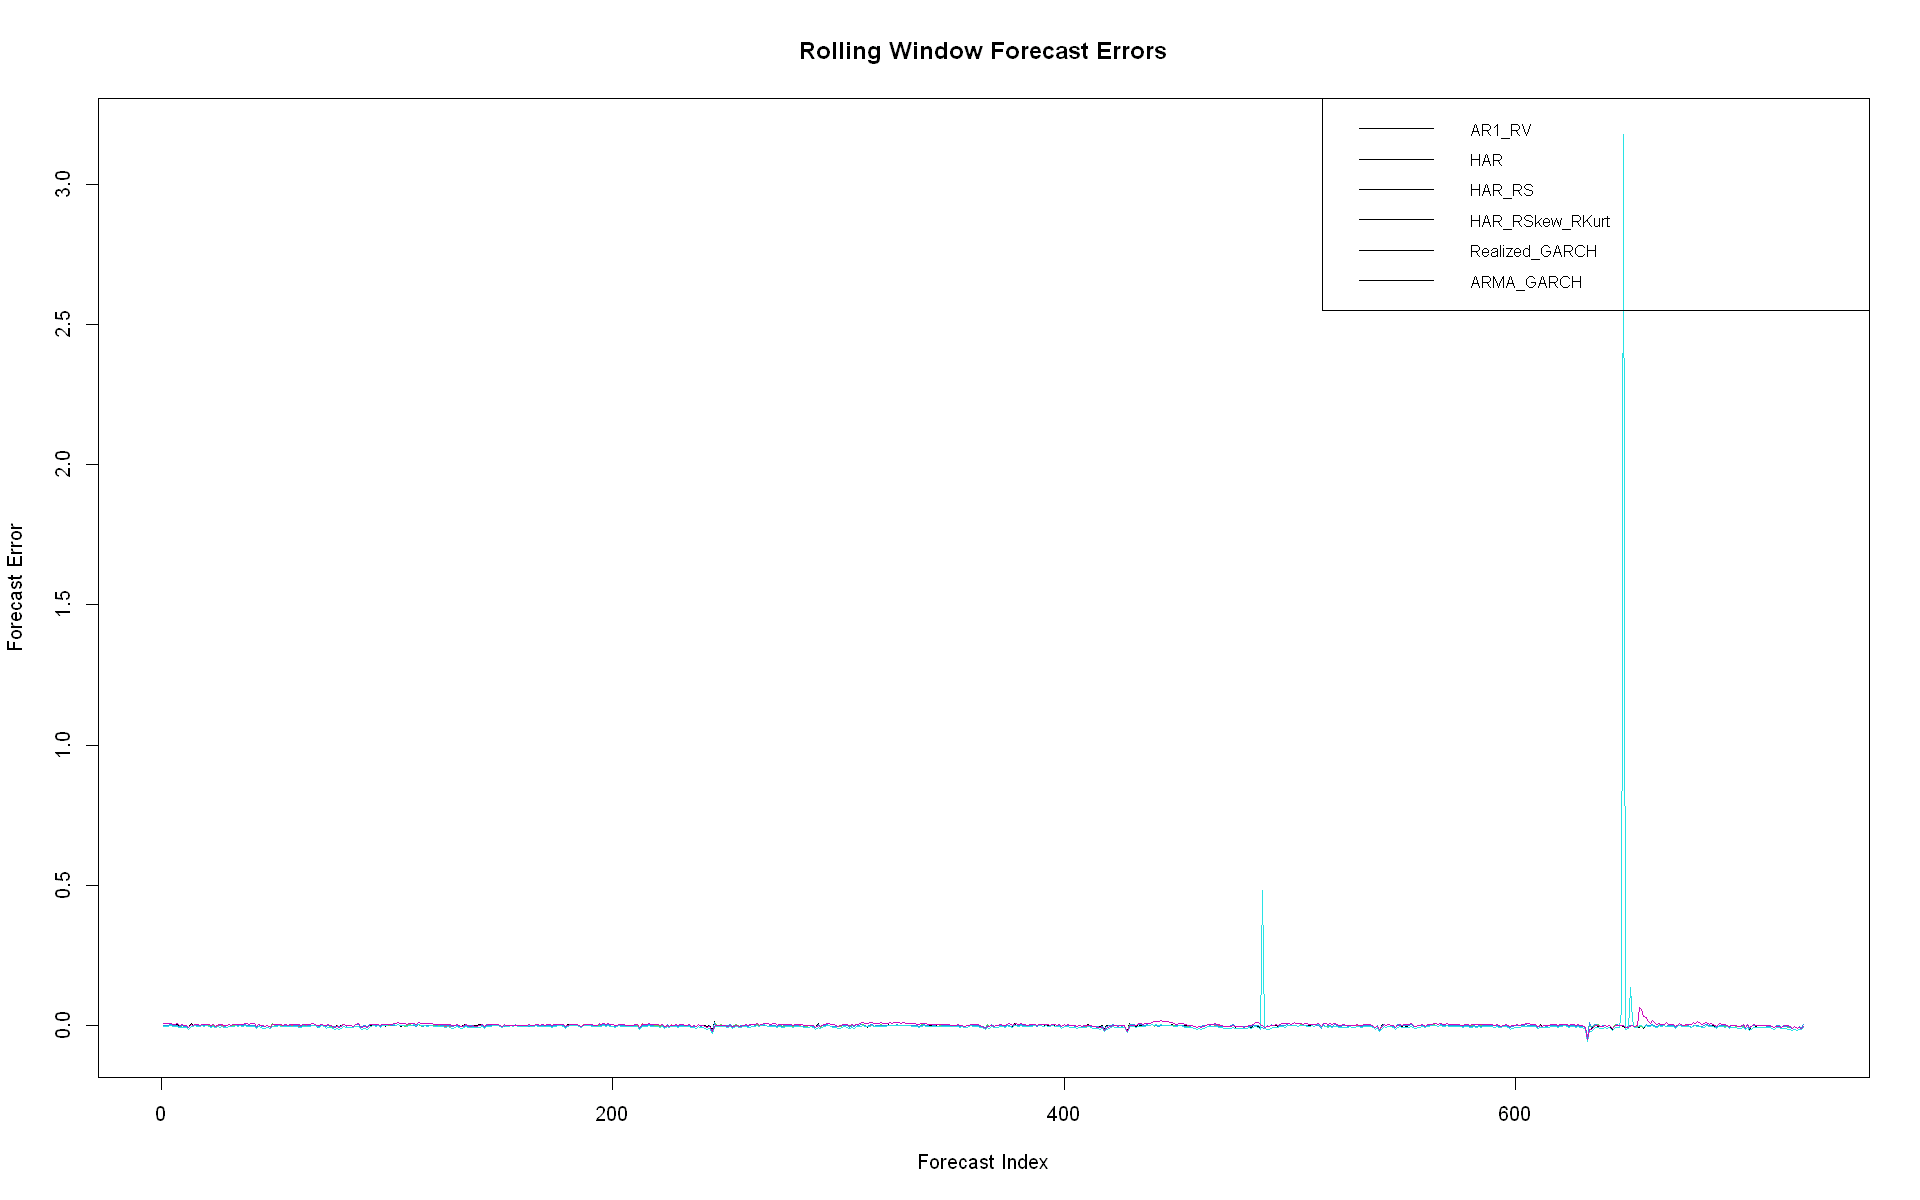

In [33]:
options(repr.plot.width = 16,
        repr.plot.height = 10)

matplot(
  exp_errors,
  type = "l",
  lty = 1,
  main = "Expanding Window Forecast Errors",
  xlab = "Forecast Index",
  ylab = "Forecast Error"
)

legend(
  "topright",
  legend = colnames(exp_errors),
  lty = 1,
  cex = 0.8
)

matplot(
  roll_errors,
  type = "l",
  lty = 1,
  main = "Rolling Window Forecast Errors",
  xlab = "Forecast Index",
  ylab = "Forecast Error"
)

legend(
  "topright",
  legend = colnames(roll_errors),
  lty = 1,
  cex = 0.8
)

### Part 4: Summary of Model Performance

In this project, we evaluated the out-of-sample forecasting performance of six volatility models for Asset 29 using both expanding and rolling windows (starting length = 750). Overall, the HAR-family models consistently outperformed the traditional GARCH specifications across all evaluation metrics.

Looking at the loss functions, the HAR models produced highly accurate forecasts. The HAR-RSkew-RKurt model performed the best overall, with the lowest MSE (approximately 1.15e-05 to 1.16e-05) in both forecasting schemes. On the other hand, the GARCH models struggled out-of-sample. The Realized GARCH was particularly unstable in the rolling window, suffering a massive error spike that drove its MSE up to 1.42e-02.

The Diebold-Mariano tests confirm that this performance gap is statistically significant. The near-zero p-values prove that the GARCH models performed significantly worse than the HAR family. Furthermore, the tests show that the HAR-RSkew-RKurt model genuinely beats the standard HAR model at the 5% significance level. The Mincer-Zarnowitz regressions highlight the same trend. The HAR models effectively captured the variance of the out-of-sample volatility, showing slopes close to 1 and explaining roughly 30% of the variance. On the other hand, the GARCH models completely fell apart, showing near-zero R-squared values and statistically insignificant slopes.

Ultimately, this analysis highlights the massive advantage of using high-frequency realized volatility data over daily returns. While adding extra parameters can sometimes cause a model to overfit in-sample noise, our out-of-sample results prove otherwise. Factoring in the shape of the return distribution through realized skewness and kurtosis provided real predictive value, making the HAR-RSkew-RKurt model the clear winner for forecasting Asset 29.